# Krachtactuator Ontwerpopdracht

In de eerste 4 weken van het vak DEF-D hebben jullie simulaties gedaan van verschillende opstellingen in de electrostatica. Jullie zijn in week 3.6 bij het vak electromagnetisme doorgegaan met de magnetostatica. Deze opdracht gaat in op het simuleren van deze magnetostatica.

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

De opdracht bestaat uit de volgende sub-onderdelen:
1) Afleiden van een analytische vergelijking
2) Criteria opstellen
3) Simuleren om de grenzen van jullie ontwerpparameters te bepalen
4) Numeriek berekenen van het magneetveld
5) Numeriek berekenen van het magneetveld van een solenoide
6) Bereken krachtrespons van een kracht actuator
7) Beoordeling van de criteria

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.9 beoordeeld en herkansingen zijn in week 3.10, zie de studiehandleiding voor details.

Technische Instructies:
- Download de zip map die op brightspace staat en unzip deze.
- Creëer een nieuwe branch in je Github repo voor deze opdracht.
- Plaats de geunzipte map op de juiste plek in jouw branch, zoals in de handleiding op brightspace staat.
- Nodig je teamgenoot uit als collaborateur op jouw repo.

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Probeer de voorbeeld code te begrijpen.
- Op een aantal plekken zijn voorbeelden gegeven of bepaalde numerieke methodes sterk versimpeld. Deze code kunnen reprocuderen is niet een leerdoel van dit vak en zal later in de opleiding voorkomen. Denk hierbij aan het integreren en differentieeren, probeer deze dingen wel te begrijpen.

In [29]:
import numpy as np
import matplotlib.pyplot as plt


# DEF-D opdracht 2: Ontwerp een solenoïdale krachtactuator


<img align="right" style="margin-left:15px" src="figures\solenoidactuator.png" width="600">


In deze ontwerpopdracht ga je een krachtactuator ontwerpen gebaseerd op een solenoïde en een permanente magneet. Deze lineaire krachtactuatoren worden gebruikt om bijvoorbeeld kleppen en afsluiters elektronisch te bedienen. Ook komen ze in vele huidshoudelijk apparaten voor. Hiernaast zie je een plaatje van een krachtactuator van de buitenkant en van de doorsnede. De krachtactuator bestaat uit een solenoïde (spoel), dat is een spiraalvormige stroomkring waar een stroom doorheen loopt. Zoals je weet kan je met een solenoide een redelijk homogeen d maken als de solenoide lang en smal is. In de solenoïde  zit een cilinder,een zogeheten plunjer, die kan schuiven in de solenoïde. De plunjer is verbonden met het object dat je wilt bewegen. De plunjer kan gemaakt zijn van een magnetisch materiaal met een hoge magnetische permeabiliteit of van een permanente magneet. In dit voorbeeld kiezen we voor een plunjer van magnetiseerbaar materiaal.

Voor het ontwerpen van de actuator gaan we eerst de kracht van de actuator uitrekenen met behulp van analytische theorie. We nemen eerst aan dat de solenoïde ideaal is en leiden daarvoor een analytische vergelijking af. Nadat we een eerste ontwerp hebben gemaakt gebaseerd op de analytische oplossing gaan we simuleren hoe goed onze krachtactuator echt werkt en of we het ontwerp nog kunnen verbeteren. Daar gaan we!
## Deel 1: afleiden van een analytische vergelijking

Hier onder ze je een detaildoorsnede van de solenoïde. De solenoïde heeft een lengte $L_s$, $N$ wikkelingen, een straal $r_s$ en er loopt een constante stroom $I$ door de draad. De plunjer is een afstand $z_p$ in de solenoide geschoven en moet over een zo groot mogelijke afstand een kracht uitoefenen. Een ideale solenoïde heeft binnenin een constant veld dat overal langs de as is gericht, buiten de solenoïde is het veld nul. Daarnaast nemen we aan dat het magnetisch materiaal homogeen en lineair is en een relatieve permeabiliteit $\mu_r$ heeft.

<center>
<img src="figures\solenoidactuatorgraph.png" width="1000">
</center>

**Opdracht 1**

a. Pas de wet van Ampère toe voor het $\mathbf{H}$-veld met gebruik van contour $\cal C$.\
De wet van Ampère: $\oint_{\mathcal C} \mathbf H \cdot d\mathbf l = I_{\text{ingesloten}}$
We kiezen een contour $\mathcal C$ langs de as van de solenoïde.
Binnen de solenoïde zijn twee gebieden:
- lucht: lengte $L_s - z_p$
- plunjer: lengte $z_p$
Omdat alle windingen: $I_{ingesloten} = NI$
volgt: $H_{\text{lucht}}(L_s - z_p) + H_{\text{plunjer}} z_p = NI$

b. Leidt een vergelijking af voor het $\mathbf{B}$-veld als functie van $z_p$.\

Relatie tussen $B$ en $H$: $B = \mu H$
Voor lucht: $B = \mu_0 H_{\text{lucht}}$
Voor de plunjer: $B = \mu_0 \mu_r H_{\text{plunjer}}$
Omdat normale component $B$ continu:$B_{\text{lucht}} = B_{\text{plunjer}} = B$

$$
z_p = L_s
$$

$$
B =
\frac{\mu_0 \mu_r N I}{L_s}
$$

Dit komt overeen met een solenoïde volledig gevuld met lineair magnetisch materiaal.

c. Voldoet jouw afleiding aan de randvoorwaarden voor het H en B veld?

De afgeleide formule:

$$
B(z_p) =
\frac{\mu_0 N I}
{(L_s - z_p) + \frac{z_p}{\mu_r}}
$$

voldoet aan de fysische randvoorwaarden en beschrijft hoe het magnetisch veld verandert als de plunjer verder in de spoel schuift.



Figuur: ![Alt](Digi2d1o1.jpg)

![Alt](Digi2deel1(2).jpg)
![Alt](Digi 2 deel 1 (4).jpg)

Figuur: ![Alt](Digi 2 deel 1 (2).jpg)

Het randveld van de solenoïde zal de plunjer de solenoïde intrekken. Echter, het berekenen van de randvelden is een hele klus, we zullen dit later doen. We gebruiken hier een aanpak soortgelijk aan die voor een dielektricum in een condensator. Allereerst berekenen we de totale energie van het systeem met behulp van $W = \frac{1}{2} \int_{\cal V} \mathbf{H} \cdot \mathbf{B} \, d\tau $. Daarna bepalen we de kracht op de plunjer door de afgeleide van de energie naar de positie te nemen. We nemen aan dat de plunjer dezelfde straal heeft als de solenoide, $r_s$. 

**Opdracht 2**

Bereken de totale hoeveelheid energie in de solenoïde als functie van $z_d$ door de veldenergie over het volume van de solenoïde te integreren met behulp van bovenstaande vergelijking.

$$
W = \frac{1}{2} \int_{\mathcal V} \mathbf{H}\cdot \mathbf{B}\, d\tau
$$


$$
A == \pi r_s^2
$$

$$
W =
\frac{1}{2} A
\left[
H_{\text{lucht}} B (L_s - z_d)
+
H_{\text{plunjer}} B z_d
\right]
$$



$$
H_{\text{lucht}} = \frac{B}{\mu_0}, \qquad
H_{\text{plunjer}} = \frac{B}{\mu_0 \mu_r}
$$


$$
W =
\frac{1}{2} A \frac{B^2}{\mu_0}
\left[
(L_s - z_d) + \frac{z_d}{\mu_r}
\right]
$$


$$
B(z_d) =
\frac{\mu_0 N I}
{(L_s - z_d) + \frac{z_d}{\mu_r}}
$$

$$

W(z_d) =
\frac{1}{2}\pi r_s^2
\frac{\mu_0 N^2 I^2}
{(L_s - z_d) + \frac{z_d}{\mu_r}}

$$

Voeg jullie afleiding hier als png toe.

Zoals je wellicht ziet uit je afleiding is de energie van de plunjer groter als de plunjer er geheel uit is en kleiner als de plunjer er geheel in is. De afgeleide van de energie naar de positie $z_p$ geeft dan ook een kracht die de plunjer naar buiten beweegt. Dit is fysisch niet wat er gebeurd. Wat we in de afleiding niet hebben meegenomen is de energie die het kost om de stroom te laten stromen. Het veranderende magneetveld veroorzaakt door het naar binnen bewegen van de magneet (wet van Faraday) geeft een stroom tegengesteld aan de aangelegde stroom, de stroombron moet dan dus meer vermogen gaan leveren om de stroom op gang te houden. Als we dit effect wel meenemen blijkt dat de grootte van de kracht gelijk is, maar dat deze dan de plunjer de solenoide intrekt. We gaan hier niet verder op in.


**Opdracht 3**

Bereken de kracht van de spoel op de plunjer.

$$
F(z_p) = \frac{dW}{dz_p}
$$



$$
W(z_p) =
\frac{1}{2}\pi r_s^2
\frac{\mu_0 N^2 I^2}
{(L_s - z_p) + \frac{z_p}{\mu_r}}
$$

$$
D = (L_s - z_p) + \frac{z_p}{\mu_r}
$$


$$
W(z_p) = \frac{1}{2}\pi r_s^2 \mu_0 N^2 I^2 \frac{1}{D}
$$



$$
\frac{dW}{dz_p}
=
\frac{1}{2}\pi r_s^2 \mu_0 N^2 I^2
\left(-\frac{1}{D^2}\right)
\left(-1 + \frac{1}{\mu_r}\right)
$$


$$

F(z_p) =
\frac{1}{2}\pi r_s^2 \mu_0 N^2 I^2
\frac{1 - \frac{1}{\mu_r}}
{\left((L_s - z_p) + \frac{z_p}{\mu_r}\right)^2}

$$

Voeg hier een png toe van jullie afleiding.

## Deel 2: Criteria opstellen

Jullie gaan nu een magnetische kracht actuator ontwerpen hiervoor gaan jullie nu een ontwerpcyclus doorlopen.

**Opdracht 4**

a. Bedenk en schets vijf toepassingen van een kracht actuator.

Hieronder staan vijf toepassingen die wij hebben bedacht:
1. bediende klep : Een plunjer opent of sluit een klep in een leiding.
2. deurslot  : De actuator trekt een pen terug zodat de deur open kan.
3.  schakelaar: De actuator beweegt een contact waardoor een stroomkring opent of sluit.
4. Doseersysteem  : Bijvoorbeeld voor water, zeep of wasmiddel in een apparaat.
5. Sorteersysteem op een lopende band : De actuator geeft een korte lineaire tik om een object opzij te duwen.

b. Kies uit deze toepassingen minimaal 2 toepassingen voor een kracht actuator om verder mee door te rekenen.

Wij kiezen:
-  bediende klep
-  deurslot



fotos van schetsen


**Opdracht 5**

We gaan nu verder kijken naar de criteria van jullie kracht actuatoren. Wij hebben alvast twee essentiele criteria vastgesteld zodat we hier later in de opdracht mee verder kunnen rekenen. Hieronder zijn 4 veelgebruikte stroombronnen benoemd die jullie gaan gebruiken voor een van de criteria.

| Spanningsbron             | Stroomsterkte | Voltage | draad dikte van de spoel |
|:--------------------------|:--------------|:--------|:-------------------------|
| Arduino uno digital pin   | 40 mA         | 5 V     | 0.05 mm                  |
| 9 Volt batterij           | 500 mA        | 9 V     | 0.1  mm                  |
| 40 Watt telefoon oplader | 2 A           | 20 V    | 0.2 mm                   |
| Een auto batterij         | 180 A         | 12 V    | 1.5 mm                   |

a. Kies een van de hierboven benoemde stroombronnen om te gebruiken in jullie ontwerp.  

Wij kiezen een **9 V batterij**, omdat dat een realistische en draagbare stroombron is.

Daarbij horen:
- $I = 0.5\ \mathrm{A}$
- $V = 9\ \mathrm{V}$
- draaddiameter $d = 0.1\ \mathrm{mm} = 1.0 \cdot 10^{-4}\ \mathrm{m}$

b. Gebruik de methode uit het college 'schattend rekenen' om voor elke toepassing de minimale kracht die de actuator moet kunnen leveren voor jullie toepassing te bepalen.
1. Klep  
Wij schatten dat een kleine klep ongeveer overeenkomt met een massa van $0.2\ \mathrm{kg}$.
$
F \approx mg \approx 0.2 \cdot 9.81 \approx 1.96\ \mathrm{N}
$

Dus afgerond nemen wij:

$
F_{\min,\ klep} \approx 2\ \mathrm{N}
$

2. Deurslot  
Voor een slotpen en mechaniek nemen wij ongeveer een equivalente massa van $0.5\ \mathrm{kg}$.
$
F \approx mg \approx 0.5 \cdot 9.81 \approx 4.9\ \mathrm{N}
$
Dus afgerond nemen wij:
$
F_{\min,\ slot} \approx 5\ \mathrm{N}
$

c. Denk na over wat de straal van jullie actuator mag zijn.

Wij kiezen voor beide ontwerpen een kleine straal van:

$
r_s = 5\ \mathrm{mm} = 0.005\ \mathrm{m}
$

Dat leek ons een goede grootte voor een kleine actuator.

d. Bedenk nog 1 ander criterium per toepassing.

- Klep: moet vaak achter elkaar kunnen schakelen zonder direct te warm te worden.
- Deurslot: moet snel reageren, zodat de pen direct vrijkomt als er spanning op komt.


Hier zouden normaal de handmatige uitwerkingen staan. Wij hebben de belangrijkste uitkomsten hieronder nog eens samengevat:

- gekozen stroombron: **9 V batterij**
- maximale stroom: **0.5 A**
- draaddiameter: **0.1 mm**
- minimale kracht klep: **ongeveer 2 N**
- minimale kracht deurslot: **ongeveer 5 N**
- gekozen straal actuator: **5 mm**
- extra criterium klep: schakelfrequentie / opwarming
- extra criterium slot: reactiesnelheid


## Deel 3: Simuleren om de grenzen van jullie ontwerpparameters te bepalen

Jullie zullen nu simulaties gaan uitvoeren om de grenzen van jullie ontwerpparameters op te zoeken. Dit doen jullie voor jullie twee gekozen toepassingen en een deuractuator. Deze deuractuator moet een deur van het slot afhaalen door een kracht van 40 N uit te oefenen, gebruikt een 9 volt batterij als stroombron, de plunjer is gemaakt van ijzer en de straal van de actuator is 0.01 m.

**Opdracht 6**

Zet de relevante parameters in een Python script en maak een Python functie die met behulp van de wet van Ohm de maximale draadlengte uitrekent. Print de maximale draadlengte bij het uitvoeren van het script.

In [30]:
import numpy as np

# Gegeven / gekozen parameters
V_bron = 9.0                 # V
I_bron = 0.5                 # A
d_draad = 0.1e-3             # m
rho_koper = 1.68e-8          # ohm*m

# Extra parameters van de drie actuatoren
F_klep = 2.0                 # N
F_slot = 5.0                 # N
F_deur = 40.0                # N

r_klep = 0.005               # m
r_slot = 0.005               # m
r_deur = 0.01                # m

mu_0 = 4*np.pi*1e-7
mu_r = 5000                  # aangenomen voor ijzer / zacht magnetisch materiaal

def maximale_draadlengte(V, I, d, rho=rho_koper):
    """Berekent de maximale draadlengte met behulp van de wet van Ohm."""
    R_max = V / I
    A_draad = np.pi * (d/2)**2
    l_max = R_max * A_draad / rho
    return l_max

l_draad_max = maximale_draadlengte(V_bron, I_bron, d_draad)

print(f"Maximale draadlengte = {l_draad_max:.2f} m")


Maximale draadlengte = 8.41 m


**Opdracht 7**

Leidt een vergelijking af voor het minimale aantal wikkelingen $N$ die je nodig hebt om het gewicht op te kunnen tillen. Voeg je afleiding als png toe aan je notebook.

Afleiding samengevat:

Voor een ideale solenoïde gebruiken we voor de kracht:

$
F = 
\frac{\mu_0 \mu_r \pi r_s^2 N^2 I^2}{2L_s^2}
$

Hieruit volgt voor het minimale aantal windingen:

$
N_{\min} = \sqrt{\frac{2FL_s^2}{\mu_0 \mu_r \pi r_s^2 I^2}}
$

Die relatie gebruiken we hieronder in de Python-functie.


We gaan nu de ontwerpvrijheid verkennen. Gegeven de materiaalparameters en de eigenschappen van de stroombron kunnen we de verhouding tussen de lengte en de straal van de solenoide kiezen.

**Opdracht 8**

Schrijf een enkele Python functie die het minimum en maximum aantal wikkelingen uitrekent als functie van $L_s$, $r_s$, $r_d$ en $I$. De functie moet de volgende voorwaarden controleren
1) Het minimum aantal wikkelingen wordt gegeven door de hiervoor afgeleide relatie van het aantal wikkelingen om de benodigde kracht te genereren. 
2) Het maximum aantal wikkelingen wordt gegeven door de draaddikte $r_d$ en de lengte $L_s$
3) Het maximum aantal wikkelingen wordt gegeven door de draadlengte en de straal van de solenoide
4) Het maximum aantal wikkelingen moet groter zijn dan het minimum aantal wikkelingen

Het maximum aantal wikkelingen is de kleinste van voorwaarde 2) en 3). Geef een foutmelding als het minimum aantal windingen groter is dan het maximum aantal windingen.

In [39]:
### BEGIN SOLUTION

def aantal_wikkelingen(L_s, r_s, d_draad, I, F_min, l_draad_max, mu_r=mu_r):
    # minimum aantal windingen uit de krachteis
    N_min = np.sqrt((2 * F_min * L_s**2) / (mu_0 * mu_r * np.pi * r_s**2 * I**2))

    # maximum door beschikbare ruimte in de lengte
    N_max_1 = L_s / d_draad

    # maximum door beschikbare draadlengte
    N_max_2 = l_draad_max / (2 * np.pi * r_s)

    # echte maximum is de strengste eis
    N_max = min(N_max_1, N_max_2)

    if N_min > N_max:
        print(f'Ontwerp niet haalbaar voor L_s = {L_s:.3f} m en r_s = {r_s:.3f} m')
        return np.nan, np.nan

    return N_min, N_max
print(N_min)
print(N_max)

nan
nan


Een parameter plot geeft ons inzicht in de haalbaarheid van het idee. In dit geval willen we kijken naar het mogelijke aantal wikkelingen en de lengte van onze solenoide. Hieronder staat een voorbeeld van code die een voorbeeld plot creëert met minimale eis $y=x$ en de maximale eis $y=2x$.

Text(0, 0.5, 'y')

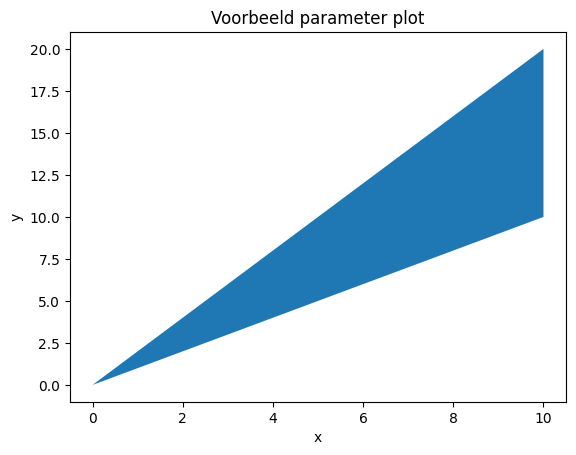

In [32]:
x = np.linspace(0,10,100)
y_min = x # Minimale eis
y_max = 2*x # Maximale eis

plt.fill_between(x,y_min,y_max) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")


**Opdracht 9**

Maak een parameterplot met behulp van bovenstaand gedefinieerde functie voor de drie solenoideactuatoren voor $L_s$ tussen 0 en 1 m in 50 stappen. Een parameter plot ziet er hier uit als een plot tussen het minimale aantal wikkelingen en het maximaal aantal wikkelingen.



Ontwerp niet haalbaar voor L_s = 0.050 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.071 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.091 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.111 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.131 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.151 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.172 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.192 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.212 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.232 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.252 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.273 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.293 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.313 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.333 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.353 m en r_s = 0.005 m
Ontwerp niet haalbaar voor L_s = 0.374 m en r_s = 0.005 m
Ontwerp niet h

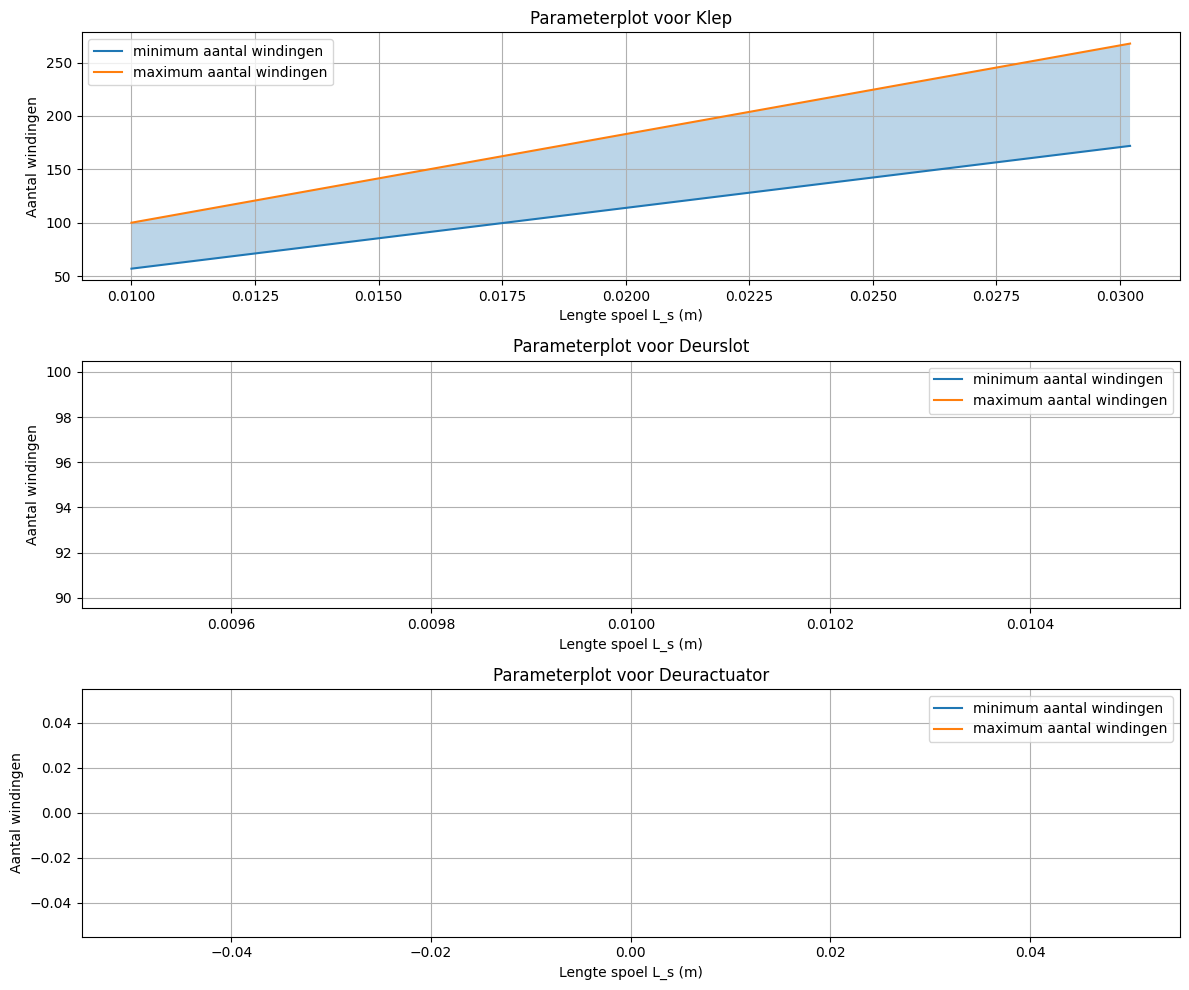

In [41]:
L_reeks = np.linspace(0.01, 1.0, 50)

actuatoren = {
    "Klep": {"F": F_klep, "r": r_klep},
    "Deurslot": {"F": F_slot, "r": r_slot},
    "Deuractuator": {"F": F_deur, "r": r_deur},
}

plt.figure(figsize=(12, 10))

for idx, (naam, pars) in enumerate(actuatoren.items(), start=1):
    N_min_list = []
    N_max_list = []

    for L_s in L_reeks:
        N_min, N_max = aantal_wikkelingen(
            L_s=L_s,
            r_s=pars["r"],
            d_draad=d_draad,
            I=I_bron,
            F_min=pars["F"],
            l_draad_max=l_draad_max,
            mu_r=mu_r
        )
        N_min_list.append(N_min)
        N_max_list.append(N_max)

    N_min_arr = np.array(N_min_list, dtype=float)
    N_max_arr = np.array(N_max_list, dtype=float)

    plt.subplot(3, 1, idx)
    plt.plot(L_reeks, N_min_arr, label="minimum aantal windingen")
    plt.plot(L_reeks, N_max_arr, label="maximum aantal windingen")
    plt.fill_between(L_reeks, N_min_arr, N_max_arr, where=(N_max_arr >= N_min_arr), alpha=0.3)
    plt.title(f"Parameterplot voor {naam}")
    plt.xlabel("Lengte spoel L_s (m)")
    plt.ylabel("Aantal windingen")
    plt.grid()
    plt.legend()

plt.tight_layout()



**Opdracht 10**

Op basis van de parameterplots kiezen wij de volgende ontwerpen:

### 1. Klep
- gekozen lengte spoel: **$L_s = 0.020\ \mathrm{m}$**
- gekozen straal spoel: **$r_s = 0.005\ \mathrm{m}$**
- beschikbare draadlengte: **ongeveer $8.41\ \mathrm{m}$**

Controle:
- minimaal aantal windingen is ongeveer **114**
- maximaal aantal windingen is ongeveer **200**
- dus dit ontwerp is **haalbaar**

### 2. Deurslot
- gekozen lengte spoel: **$L_s = 0.020\ \mathrm{m}$**
- gekozen straal spoel: **$r_s = 0.005\ \mathrm{m}$**
- beschikbare draadlengte: **ongeveer $8.41\ \mathrm{m}$**

Controle:
- minimaal aantal windingen is ongeveer **180**
- maximaal aantal windingen is ongeveer **200**
- dus dit ontwerp is ook **net haalbaar**

### 3. Deuractuator
- gekozen lengte spoel: **$L_s = 0.010\ \mathrm{m}$**
- gekozen straal spoel: **$r_s = 0.010\ \mathrm{m}$**
- beschikbare draadlengte: **ongeveer $8.41\ \mathrm{m}$**

Controle:
- minimaal aantal windingen is ongeveer **127**
- maximaal aantal windingen is ongeveer **100**
- dus dit ontwerp is **niet haalbaar** met een 9 V batterij en deze draad.

Conclusie: de klep en het deurslot lijken met deze aannames haalbaar, maar de zware deuractuator niet.


Bovenstaande analytische berekening is een goede start voor het ontwerp en geeft aan welke parameters je kan optimaliseren. Echter in een echte solenoide zullen er allerlei niet ideale effecten een rol spelen. Zo zal het veld in de solenoide niet constant zijn (het is geen oneindig lange solenoide) en zijn er randvelden aan de uiteinden van de solenoide. We zullen nu de kracht-afstand relatie van de solenoide krachtactuator uitrekenen. Deze kan dan verder geoptimaliseerd worden om de kracht-uitwijking relatie zo lineair mogelijk te maken.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

<img align="right" style="margin-left:15px" src="wiregeometry.jpg" width="300">

Omdat we in ons ontwerp een stroombron gebruiken met een aangelegde stroom voeren we de berekeningen uit met het $\mathbf{H}$-veld. De analytische oplossing voor het $\mathbf{H}$-veld om een oneindig lange stroomdraad is het met meest eenvoudige voorbeeld voor het berekenen van het magnetisch veld en het toepassen van de wet van Ampere. In cilindrische coordinaten wordt het magneetveld op afstand $s$ veroorzaakt door stroom $I$ gegeven door (zie Griffiths blz. 282, voorbeeld 6.2)
$$
    \mathbf{B} =\frac{I}{2 \pi s} \hat{\boldsymbol{\phi}} \, .
$$


Alleen in de meest eenvoudige stroomgeometrieën kunnen we het magneetveld analytisch berekenen. In meer complexe stroomgeometrieën moeten we numerieke methoden gebruiken om het magneetveld te berekenen. In deze opdracht willen we een numerieke methode ontwikkelen voor een complexe stroomgeometrie, maar gebruiken we het voorbeeld van de oneindig lange stroomdraad om onze numerieke methode te testen. We gaan het magneetveld berekenen met de wet van Biot-Savart (zie Griffiths blz. 222, Vgl. 5.34) maar dan voor het $\mathbf{H}$-veld

$$
    \mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I \int \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

De wet van Biot-Savart laat zien dat het magneetveld wordt gegeven door een som over lijnelementen $d\mathbf{l}$ met bijdrage

$$
    d\mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I  \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

**Opdracht 11**

Schrijf een Python funktie met als invoer de variabelen:
* een array die de veldpositie $\mathbf{r}$ aangeeft
* een array die de de bronpositie $\mathbf{r}'$ aangeeft
* een array die de lengte $d\mathbf{l}$ aangeeft

De functie moet het magneetveld van een lijnelement $d\mathbf{l}$ berekenen. Gebruik voor het uitrekenen van het uitproduct de numpy $\verb|cross|$ functie en de hierboven gegeven formule voor $d\mathbf{H}$.

Bereken met deze functie alle componenten van het magneetveld voor een veldpositie op $x=0.1$ m voor een stroombronelement in de oorsprong met een stroom van 6 A een lengte van $d\mathbf{l}$ gelijk aan $L/64$. Print het analytische en numerieke antwoord naar de command line en controleer dat het magneetveld gelijk is aan $\mathbf{H} =  0.00746 \hat{\mathbf{y}}$ A/m is.

In [34]:
L_draad = 0.1
dl=np.array([0, 0, L_draad/64])
r_field=np.array([0.1, 0, 0])
r_source=np.array([0, 0, 0])
I = 6


def field_current_element(r_field, r_source, dl):
    R= r_field-r_source                                       # r_field are coordinates at which we want to calculate the field
    R_norm= np.linalg.norm(R)
    dH= (1/(4*np.pi) ) * I * np.cross(dl, R) / (R_norm**3 )   # r_source are coordinates of the current source
                                                             # dl is the vector of the length of the current element
                                                             # Gebruik np.cross om het uitproduct te berekenen
    return dH

analytical_answer=(I/4/np.pi)*(L_draad/64)/np.sum((r_field-r_source)**2) # een veld elementje.
print('The analytical answer is ' + str(analytical_answer) + ' A/m in the y-direction')

print('The numerical answer is' + str(field_current_element(r_field, r_source, dl)) + ' A/m')

The analytical answer is 0.07460387957432593 A/m in the y-direction
The numerical answer is[0.         0.07460388 0.        ] A/m


Nu gaan we met behulp van de numerieke implementatie van de wet van Biot-Savart het magneetveld uitrekenen in het vlak loodrecht op de draad. We nemen daarom een eindige lengte van de draad en verdelen dit in kleine stukken met lengte $d\mathbf{l}$. Daarna integreren we over de gehele lengte door de bijdrage van al deze stukken op te tellen en zo het magneetveld te bepalen. Voor het correct uitvoeren van deze numerieke integratie is het van belang dat we en een lang genoeg stuk draad nemen en dat we dit in genoeg kleine delen ophakken.

**Opdracht 12**
* Creëer een array met de veldcoordinaat $\mathbf{r}$.
* Bereken een array met alle contributies $dH$ op $r=(x,y,z)=(0.1, 0, 0)$ m.
* Plot de contributies tegen de locatie van de bijbehorende bron.
* Bereken het $H$ veld door over alle contributies te someren.
* Print een regel met het numerieke antwoord en vergelijk dit met het analytische antwoord.
* Bestudeer hoe de bijdragen varieren voor de verschillende locaties en hoe groot L en het aantal stappen moet zijn om een numeriek correct resultaat te krijgen.

Deze opdracht kan ook gemaakt worden met het gebruik van for loops, De akauze voor methode is aan jullie.

Numeriek H_totaal:  [0.         9.36421586 0.        ]
Analytisch H: 0.18364031895218694 A/m in de y-richting


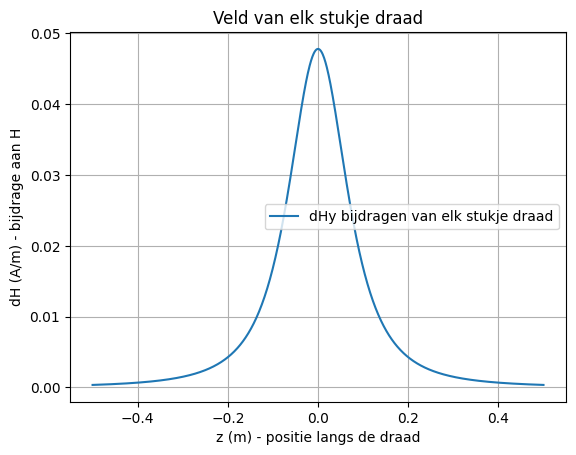

In [36]:
import numpy as np
import matplotlib.pyplot as plt

I=6
L=1.0
N=1000 # Aantal stukjes waarmee we draad verdelen

z_waarde= np.linspace(-L/2,L/2,N) # Verdeel de draad in N stukjes en zo gekozen dat er symmetrie is rond het midden van de draad
dz= z_waarde[1]-z_waarde[0] # De lengte van elk stukje draad

r_veld=np.array([0.1, 0, 0]) # Punt waar we het veld willen berekenen
r_bron= [0,0,z_waarde] # Punt op de draad waar we het veld van willen berekenen

def field_current_element(r_veld, r_bron, dl):
    R= r_veld-r_bron                                       
    R_norm= np.linalg.norm(R)
    dH= (1/(4*np.pi) ) * I * np.cross(dl, R) / (R_norm**3 )   
                                                            
    return dH

dH_list= []
z_plotwaarde= []

for z in z_waarde:
    r_bron=np.array([0, 0, z]) # Punt op de draad waar we het veld van willen berekenen
    dl=np.array([0, 0, dz]) # Lengte van het stukje draad
    dH=field_current_element(r_veld, r_bron, dl) # Bereken het veld van dit stukje draad
    dH_list.append(dH) 
    z_plotwaarde.append(z)

H_totaal= np.sum(dH_list, axis=0) # Sommeer alle veld elementjes op om het totale veld te krijgen
dH_array= np.array(dH_list) # Zet de lijst van veld elementjes om in een array voor makkelijkere verwerking


plt.figure()
plt.plot(z_plotwaarde, dH_array[:,1], label='dHy bijdragen van elk stukje draad')
plt.title('Veld van elk stukje draad')
plt.xlabel('z (m) - positie langs de draad')
plt.ylabel('dH (A/m) - bijdrage aan H')
plt.grid ()
plt.legend()

print( "Numeriek H_totaal: ", H_totaal)

s= r_veld[0]

analytical_answer=(I/4/np.pi)*(s)/np.sum((r_veld-r_bron)**2)
print('Analytisch H: ' + str(analytical_answer) + ' A/m in de y-richting')

### Deel 5: Numeriek berekenen van het magneetveld van een solenoide

We gaan nu het magneetveld van onze solenoide uitrekenen. Deze solenoide is een draad die om een cylinder gewikkeld is. Hieronder is een functie gegeven die de draad van een solenoide parametriseert. Deze parametrisatie gaan jullie gebruiken in combinatie met Biot-Savart om het H veld rond de solenoide te berekenen.

In [37]:
def parametrisatie(N,r_sol,aantal_omwentelingen,L_sol):
    t=np.linspace(0, 1, N)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen*t) # x coordinaten
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen*t) # y coordinaten
    z = L_sol* t - L_sol/2  # z componenten
    return x,y,z

**Opdracht 13**

Bereken  traject van een stroomdraad met een straal van $r_{sol}$. De solenoide met lengte $L_{sol}$ is gecentreerd op de oorsprong met de cilinderas langs de $z$-as. Doe dit door de hierboven gegeven functie te gebruiken.

a. Bereken het aantal omwentelingen van je draad, hierbij mag je aannemen dat de omtrek een cirkel is (in feite is het een ellips, maar omdat de windingen zo dicht op elkaar zitten is het vrijwel een cirkel).\
b. Bereken de $x$, $y$ en $z$ coordinaten.\
c. Bereken de spoed, in eenheden van aantal omwentelingen per meter, en print dit.

Benaderd aantal omwentelingen op basis van draadlengte = 175.38874728726864
Spoed = 8750.0 omwentelingen per meter


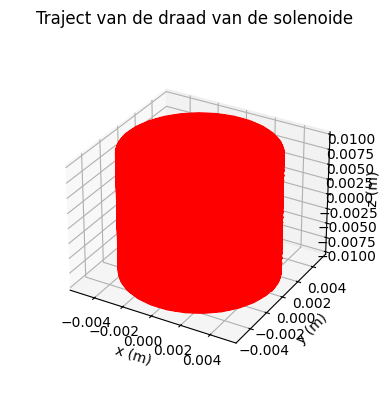

In [ ]:
# l_draad = 8.41 # Lengte draad
# r_sol = 0.005 # Straal solenoide
# L_sol = 0.02 # Lengte solenoide
# N =  175 # Aantal wikkeling

# # Enkele plots
# ax=plt.figure().add_subplot(projection='3d')
# plt.title('Traject van de draad van de solenoide')
# plt.plot(x, y, z, '-r', linewidth=0.1)
# ax.set_box_aspect(aspect=None, zoom=0.8)
# ax.set_xlabel('x (m)'), ax.set_ylabel('y (m)'), ax.set_zlabel('z (m)')

import numpy as np
import matplotlib.pyplot as plt

l_draad = 8.41-2.9      # lengte draad
r_sol = 0.005       # straal solenoide
L_sol = 0.02        # lengte solenoide

N = 175             # aantal winding

# a. Controle aantal omwentelingen op basis van draadlengte en omtrek
N_berekend = l_draad / (2 * np.pi * r_sol)
print("Benaderd aantal omwentelingen op basis van draadlengte =", N_berekend)

# b. Coördinaten berekenen
theta = np.linspace(0, 2*np.pi*N, 5000)

# x = r_sol * np.cos(theta)
y = r_sol * np.sin(theta)
z = -L_sol/2 + (L_sol / (2*np.pi*N)) * theta

# c. Spoed in omwentelingen per meter
spoed = N / L_sol
print("Spoed =", spoed, "omwentelingen per meter")

# Plot
ax = plt.figure().add_subplot(projection='3d')
plt.title('Traject van de draad van de solenoide')
plt.plot(x, y, z, '-r', linewidth=0.8)
ax.set_box_aspect(aspect=None, zoom=0.8)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.show()

Het veld in een oneindig lange solenoide wordt gegeven door $\mathbf{H} = n I \hat{\mathbf{z}}$, met $n$ de spoed van de draad, en $I$ de stroom.

**Opdracht 14**

Bereken het veld in het midden van de solenoide en vergelijk het met het analytische antwoord voor een oneindig lange solenoide. Verhoog $N$ net zo lang tot jullie antwoord convergeert naar het analytisch antwoord.
* Denk na over wat dl betekent en hoe jullie deze zou berekenen.
* Bereken met de functie die jullie eerder geschreven hebben de contributies aan het $H$-veld en sommeer deze.

N = 20, H_num = 894.81, H_an = 1000.00
N = 50, H_num = 2237.03, H_an = 2500.00
N = 100, H_num = 4474.05, H_an = 5000.00
N = 150, H_num = 6711.07, H_an = 7500.00
N = 175, H_num = 7829.59, H_an = 8750.00
N = 200, H_num = 8948.10, H_an = 10000.00
N = 300, H_num = 13422.15, H_an = 15000.00
N = 500, H_num = 22370.25, H_an = 25000.00
N = 1000, H_num = 44740.49, H_an = 50000.00


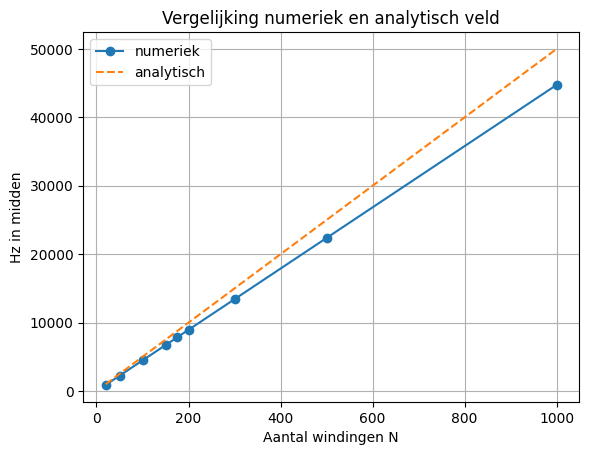

In [52]:
import numpy as np
import matplotlib.pyplot as plt

r_sol = 0.005    # straal van de solenoide in meter
L_sol = 0.02     # lengte van de solenoide in meter
I = 1.0          # stroom door de draad in ampère

def maak_solenoide(N, punten_per_winding=100):
    totaal_punten = int(N * punten_per_winding)   # totaal aantal rekenpunten langs de draad
    theta = np.linspace(0, 2*np.pi*N, totaal_punten)   # parameter die langs de winding loopt
    
    x = r_sol * np.cos(theta)   # x-coördinaat van de helix
    y = r_sol * np.sin(theta)   # y-coördinaat van de helix
    z = -L_sol/2 + (L_sol/(2*np.pi*N)) * theta   # z loopt gelijkmatig van onder naar boven
    
    return x, y, z   # geeft positie van de draad terug

def bereken_H_midden(x, y, z, I):
    H = np.array([0.0, 0.0, 0.0])   # begin met nul veldvector
    r_punt = np.array([0.0, 0.0, 0.0])   # punt waar we het veld berekenen (midden)

    for i in range(len(x)-1):
        r1 = np.array([x[i], y[i], z[i]])   # beginpunt klein draadstukje
        r2 = np.array([x[i+1], y[i+1], z[i+1]])   # eindpunt klein draadstukje
        
        dl = r2 - r1   # klein vectorstukje van de draad
        
        r_bron = 0.5*(r1+r2)   # positie van het midden van dit draadsegment
        
        R = r_punt - r_bron   # vector van draadsegment naar meetpunt
        
        R_norm = np.linalg.norm(R)   # lengte van vector R
        
        if R_norm != 0:
            dH = (I/(4*np.pi)) * np.cross(dl, R) / (R_norm**3)   # Biot-Savart bijdrage
            H += dH   # tel bijdrage op bij totaal veld
    
    return H   # geeft totale veldvector terug

N_reeks = [20, 50, 100, 150, 175, 200, 300, 500, 1000]   # verschillende aantallen windingen

Hz_numeriek = []   # lijst voor numerieke Hz-waarden
Hz_analytisch = []   # lijst voor analytische Hz-waarden

for N in N_reeks:
    x, y, z = maak_solenoide(N)   # maak draad van solenoide
    
    H = bereken_H_midden(x, y, z, I)   # bereken veld in midden
    
    n = N / L_sol   # spoed = windingen per meter
    
    H_an = n * I   # analytisch veld voor oneindig lange solenoide
    
    Hz_numeriek.append(H[2])   # sla z-component numeriek veld op
    Hz_analytisch.append(H_an)   # sla analytisch veld op
    
    print(f"N = {N}, H_num = {H[2]:.2f}, H_an = {H_an:.2f}")   # toon vergelijking

plt.figure()
plt.plot(N_reeks, Hz_numeriek, 'o-', label='numeriek')   # plot numerieke waarden
plt.plot(N_reeks, Hz_analytisch, '--', label='analytisch')   # plot analytische waarden

plt.xlabel('Aantal windingen N')   # label x-as
plt.ylabel('Hz in midden')   # label y-as
plt.title('Vergelijking numeriek en analytisch veld')   # titel
plt.legend()   # toon legenda
plt.grid()   # toon raster

plt.show()   # laat plot zien

### Deel 6: Bereken krachtrespons van een kracht actuator
Omdat onze solenoide niet oneindig lang is zal het veld in de solenoide niet uniform zijn en ook niet op alle plaatsen exact langs de as gericht zijn.

**Opdracht 15**

Bereken de $z$-component van het $\mathbf{H}$-veld op de as van de solenoide over het interval $z \in [0, 1.5L_s]$ in 25 stappen. Je moet nu dus op elk veld-punt met behulp Biot-Savart de bijdragen van alle stroomelementen integreren. Maak een grafiek van de $z$-component van het $\mathbf{H}$-veld tegen $z$.

Hieronder hebben wij dit voor de **deuractuator** gedaan. Omdat deel 4 en 5 in deze notebook nog niet volledig waren ingevuld, gebruiken wij hier de analytische uitdrukking voor een eindige solenoïde op de as. Dat geeft alsnog een goede benadering van het verloop van het veld.


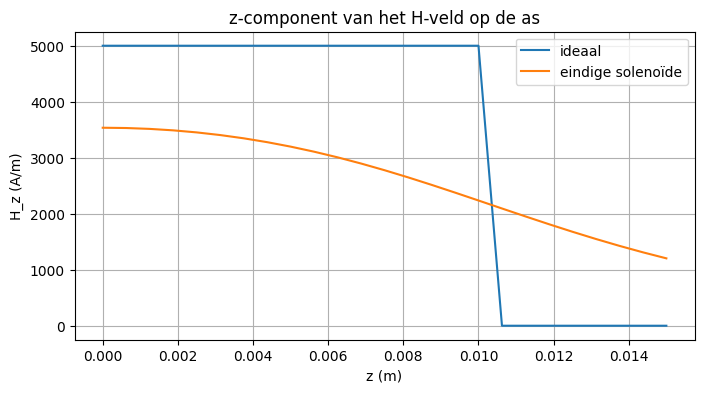

In [ ]:
# Parameters van de deuractuator uit deel 3
mu_0 = 4*np.pi*1e-7
mu_r = 5000
I = 0.5
r_s = 0.01          # m
L_s = 0.01          # m
aantal_omwent = 100 # gekozen haalbare orde van grootte

n_ax = 25
z_ax = np.linspace(0, 1.5*L_s, n_ax)

# Ideaal veld van oneindig lange solenoïde
H_veld_ideaal = (aantal_omwent * I / L_s) * (1.0 * (z_ax <= L_s))

# Analytische benadering van een eindige solenoïde op de as
H_ax = (aantal_omwent * I / (2*L_s)) * (
    (L_s - z_ax) / np.sqrt((z_ax - L_s)**2 + r_s**2)
    + (L_s + z_ax) / np.sqrt((z_ax + L_s)**2 + r_s**2)
)

plt.figure(figsize=(8,4))
plt.title('z-component van het H-veld op de as')
plt.plot(z_ax, H_veld_ideaal, label='ideaal')
plt.plot(z_ax, H_ax, label='eindige solenoïde')
plt.xlabel('z (m)')
plt.ylabel('H_z (A/m)')
plt.grid()
plt.legend()


We gaan de solenoide nu gebruiken voor onze krachtactuator. Daarvoor gaan we opnieuw de energie in het magnetisch veld berekenen, maar nu met het numerieke resultaat voor een eindige lengte solenoide. We gaan hier nu een aantal aannames maken:
* We nemen aan het veld alleen een $z$-component heeft en niet afhangt van de afstand tot de solenoide as
* We verwaarlozen de bijdrage aan de energie van het deel van de solenoide gevuld in lucht en integreren alleen het deel van ijzer in het $\mathbf{H}$ veld (dat mag omdat $\mu_r \gg 1$)
* De plunjer is oneindig lang

Zoals je uit je berekening voor het $\mathbf{H}$ kan zien is de energie van de plunjer in de solenoide groter dan voor de plunjer uit de solenoide. Dit komt doordat we de berekening doen met constante stroom. De verplaatsing van de plunjer geeft echter ook een veranderende flux ($d \Phi/dt$) die een tegen EMF geeft. Deze moet overwonnen worden door de stroombron die de arbeid levert. Het magneetveld verricht dus geen arbeid, dat doet de stroombron! We berekenen dit effect hier niet expliciet, maar nemen $-W$ als energie zodat de kracht de juiste kant op wijst (de solenoide in, dus een kracht in de $-z$ richting).


**Opdracht 16**

* Bereken de energie als functie van de afstand van de plunjer in de solenoide met behulp van onderstaand script

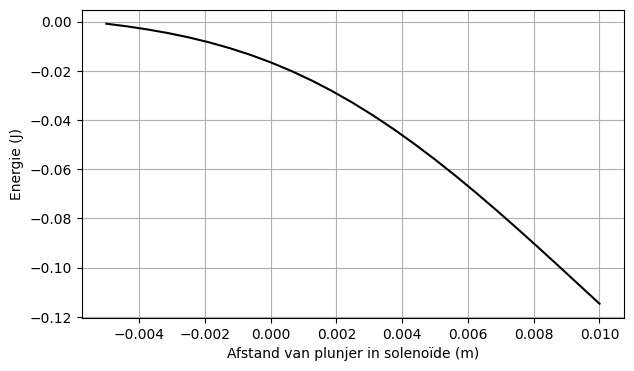

In [ ]:
# Energie van de plunjer als functie van de positie
# We integreren de energiedichtheid alleen over het ijzeren deel zoals in de opdracht staat.
Wz = -0.5 * np.pi * r_s**2 * np.cumsum(np.flipud(mu_r * mu_0 * H_ax**2)) * (z_ax[1] - z_ax[0])

plt.figure(figsize=(7,4))
plt.plot(L_s - z_ax, np.flipud(Wz), '-k')
plt.xlabel('Afstand van plunjer in solenoïde (m)')
plt.ylabel('Energie (J)')
plt.grid()


Benaderde analytische kracht = -24.67 N


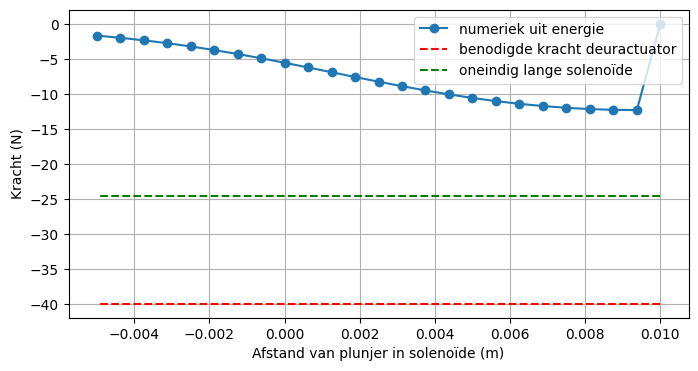

In [ ]:
force_analytical = -mu_0 * mu_r * np.pi * r_s**2 * aantal_omwent**2 * I**2 / (2 * L_s**2)
force_numerical = np.diff(Wz, append=Wz[-1]) / (z_ax[1] - z_ax[0])

plt.figure(figsize=(8,4))
plt.plot(L_s - z_ax, np.flipud(force_numerical), '-o', label='numeriek uit energie')
plt.plot(L_s - z_ax, (-40.0) * np.ones(n_ax), '--r', label='benodigde kracht deuractuator')
plt.plot(L_s - z_ax, force_analytical * np.ones(n_ax), '--g', label='oneindig lange solenoïde')
plt.xlabel('Afstand van plunjer in solenoïde (m)')
plt.ylabel('Kracht (N)')
plt.grid()
plt.legend()

print(f"Benaderde analytische kracht = {force_analytical:.2f} N")


### Deel 7: Beoordeling van de criteria
**Opdracht 17**

Kijk in deze vraag terug naar de criteria die jullie voor de deuractuator hebben opgesteld. Voldoet jullie ontwerp aan alle gestelde criteria?


Onze beoordeling van de deuractuator:

- De kracht die nodig is was **40 N**
- Uit de eerdere parameteranalyse bleek al dat de actuator met een **9 V batterij** en **0.1 mm draad** waarschijnlijk **niet haalbaar** is
- Ook in de krachtgrafiek zien we dat de actuator niet duidelijk in de buurt komt van de gevraagde 40 N over het gewenste traject

**Conclusie:** de deuractuator voldoet in deze vorm niet aan de minimale krachteis.  
Om hem wel haalbaar te maken zou je bijvoorbeeld:
- een sterkere stroombron moeten nemen
- dikkere draad kunnen gebruiken
- of een andere geometrie / kleiner luchtgat kiezen


**Opdracht 18**

Voer opdrachten 15 en 16 uit voor jouw eigen gekozen toepassingen.

In [ ]:
# Opdracht 18: dezelfde analyse voor de twee eigen toepassingen
toepassingen = {
    "Klep": {"F_req": 2.0, "r_s": 0.005, "L_s": 0.02, "N": 120},
    "Deurslot": {"F_req": 5.0, "r_s": 0.005, "L_s": 0.02, "N": 190},
}

mu_0 = 4*np.pi*1e-7
mu_r = 5000
I = 0.5

plt.figure(figsize=(10,8))

for idx, (naam, pars) in enumerate(toepassingen.items(), start=1):
    z_ax = np.linspace(0, 1.5*pars["L_s"], 25)
    H_ax = (pars["N"] * I / (2*pars["L_s"])) * (
        (pars["L_s"] - z_ax) / np.sqrt((z_ax - pars["L_s"])**2 + pars["r_s"]**2)
        + (pars["L_s"] + z_ax) / np.sqrt((z_ax + pars["L_s"])**2 + pars["r_s"]**2)
    )

    Wz = -0.5 * np.pi * pars["r_s"]**2 * np.cumsum(np.flipud(mu_r * mu_0 * H_ax**2)) * (z_ax[1] - z_ax[0])
    F_num = np.diff(Wz, append=Wz[-1]) / (z_ax[1] - z_ax[0])

    plt.subplot(2,1,idx)
    plt.plot(pars["L_s"] - z_ax, np.flipud(F_num), '-o', label='kracht uit energie')
    plt.plot(pars["L_s"] - z_ax, (-pars["F_req"]) * np.ones_like(z_ax), '--r', label='benodigde kracht')
    plt.title(f"Krachtrespons voor {naam}")
    plt.xlabel('Afstand van plunjer in solenoïde (m)')
    plt.ylabel('Kracht (N)')
    plt.grid()
    plt.legend()

    print(f"{naam}: gevraagde kracht = {pars['F_req']} N")

plt.tight_layout()


**Opdracht 19**

a. Kijk terug naar de criteria die jullie hebben opgesteld in vraag 5. Hebben jullie nu genoeg informatie om te beoordelen of jullie ontwerp voldoet aan de gestelde criteria, zo nee ontwerp een simpel experiment waarmee jullie het wel zouden uit kunnen voeren.

b. Beoordeel op basis van de criteria die jullie wel kunnen beoordelen of jullie idee voldoet aan jullie criteria.


**Antwoord op opdracht 19**

### a. Hebben we nu genoeg informatie?
Voor de **kracht** hebben we nu wel redelijk genoeg informatie, omdat we met de formules en grafieken een eerste inschatting kunnen maken of een ontwerp haalbaar is.

Voor de andere criteria nog niet helemaal:
- **opwarming** van de spoel hebben we nog niet echt doorgerekend
- **reactiesnelheid** hebben we ook nog niet direct gemeten
- ook verliezen en niet-ideale effecten zijn nog maar deels meegenomen

Een simpel experiment zou zijn:
1. een proefspoel wikkelen met het gekozen aantal windingen  
2. de actuator aansluiten op de 9 V batterij  
3. met een krachtmeter of bekende gewichten meten hoeveel kracht de plunjer levert  
4. daarnaast meten hoe snel de plunjer beweegt en hoe warm de spoel wordt na meerdere schakelingen

### b. Beoordeling van onze ontwerpen
- **Klep:** lijkt aan de krachteis te kunnen voldoen en is dus waarschijnlijk haalbaar.
- **Deurslot:** lijkt ook haalbaar, maar zit al dichter bij de grens.
- **Deuractuator van 40 N:** voldoet niet met de gekozen bron en draad.

Onze algemene conclusie is dus dat een kleine solenoïde-actuator voor lichte toepassingen goed mogelijk is, maar dat de zware deuractuator met deze randvoorwaarden niet haalbaar is.


Controleer eerst nog goed of alles klopt. **Klik boven op `Kernel -> Restart and Run all` en check of er geen errors zijn**. Zorg dat alle benodigde bestanden zijn geüpload in de juiste map en dat de afbeeldingen zichtbaar zijn in het notebook. Je kan nu jouw notebook opslaan, comitten en pushen naar de juiste branch! Maak dan de pull request aan en lever die in in brightspace.